In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from matplotlib.gridspec import GridSpec

def bufferx_radius(pts, target_pct=5.0):
    """Calculates density-aware radius"""
    pts_torch = torch.from_numpy(pts[:, :3]).float()
    indices = torch.randperm(pts_torch.shape[0])[:1000]
    kpts = pts_torch[indices]
    dist_sqr = torch.cdist(kpts.unsqueeze(0), pts_torch.unsqueeze(0)).squeeze(0)**2
    
    low, high = 0.0, 500.0 
    for _ in range(40):
        r = (low + high) / 2.0
        avg_pct = ((dist_sqr < r**2).float().sum() / (pts_torch.shape[0] * 1000)) * 100
        if avg_pct < target_pct: low = r
        else: high = r
    return r

def bufferx_voxel(pts):
    """Determines adaptive voxel size based on PCA sphericity"""
    sample_idx = np.random.choice(len(pts), int(len(pts)/10), replace=False)
    sampled = pts[sample_idx]
    pca = PCA(n_components=3)
    pca.fit(sampled)
    eigenvalues = pca.explained_variance_
    sphericity = min(eigenvalues) / max(eigenvalues)
    transformed_pts = pca.transform(pts)
    z_range = transformed_pts[:, 2].max() - transformed_pts[:, 2].min()
    
    alpha = 1.0 if sphericity < 0.05 else 1.5
    v = (np.sqrt(z_range) / 100) * alpha
    return max(v, 0.001)

def voxel_downsample(pts, voxel_size):
    """Grid-based downsampling for comparable density"""
    coords = (pts[:, :3] / voxel_size).astype(int)
    unique_indices = {}
    for i, coord in enumerate(coords):
        key = tuple(coord)
        if key not in unique_indices: unique_indices[key] = i
    return pts[list(unique_indices.values())]

def render_comparison(ref_pts, src_pts, stage_name):
    """Renders combined and side-by-side views"""
    fig = plt.figure(figsize=(20, 10))
    gs = GridSpec(2, 6, figure=fig)
    angles = [(90, -90, "Top"), (0, -90, "Side"), (-90, -90, "Bottom")]

    all_pts = np.vstack([ref_pts, src_pts])
    max_range = np.max(np.abs(all_pts)) * 1.1
    lims = [-max_range, max_range]

    for i, (elev, azim, title) in enumerate(angles):
        ax_c = fig.add_subplot(gs[0, i*2 : i*2+2], projection='3d')
        ax_c.scatter(ref_pts[:, 0], ref_pts[:, 1], ref_pts[:, 2], c='red', s=1, alpha=0.3)
        ax_c.scatter(src_pts[:, 0], src_pts[:, 1], src_pts[:, 2], c='blue', s=1, alpha=0.3)
        ax_c.set_xlim(lims); ax_c.set_ylim(lims); ax_c.set_zlim(lims)
        ax_c.view_init(elev=elev, azim=azim)
        ax_c.set_title(f"Combined {title} ({stage_name})")
        
        for j, (data, color, name) in enumerate([(ref_pts, 'red', 'Ref'), (src_pts, 'blue', 'Plank')]):
            ax = fig.add_subplot(gs[1, i*2 + j], projection='3d')
            ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=color, s=1, alpha=0.5)
            ax.set_xlim(lims); ax.set_ylim(lims); ax.set_zlim(lims)
            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f"{name} {title}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()


r_ref = 0.23843041844884283
r_plank = 24.955858857993007
Rendering: Just After Scaling...


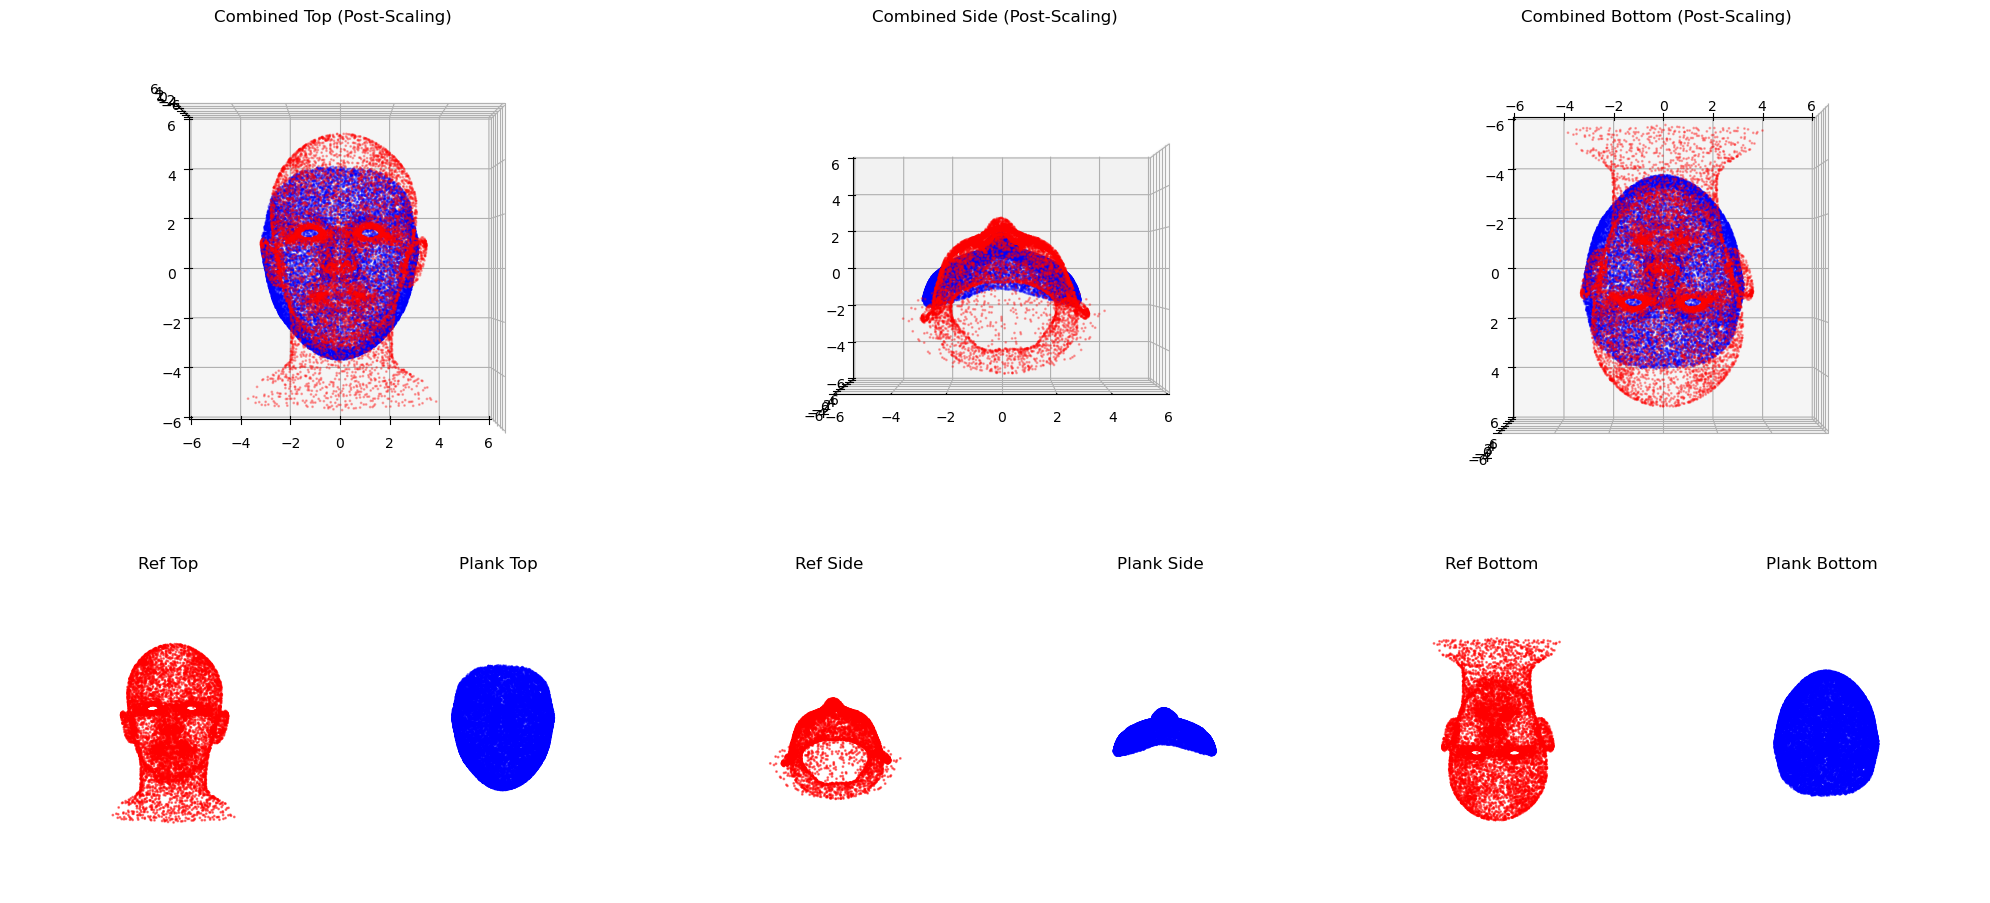

In [39]:
# Scale Alignment 
ref = np.load('ref.npy')[:, :3]
plank = np.load('plank.npy')[:, :3]

# Calculate radii to resolve scale discrepancies
r_ref = bufferx_radius(ref)
r_plank = bufferx_radius(plank)

print(f"r_ref = {r_ref}")
print(f"r_plank = {r_plank}")

# Normalize to unit scale
ref_norm = ref / r_ref
plank_norm = plank / r_plank

np.save('scaled_ref.npy', ref_norm)
np.save('scaled_src.npy', plank_norm)

print("Rendering: Just After Scaling...")
render_comparison(ref_norm, plank_norm, "Post-Scaling")


Ref-calculated Voxel Size: 0.0404
Rendering: After Voxelization (using Ref Voxel Size)...


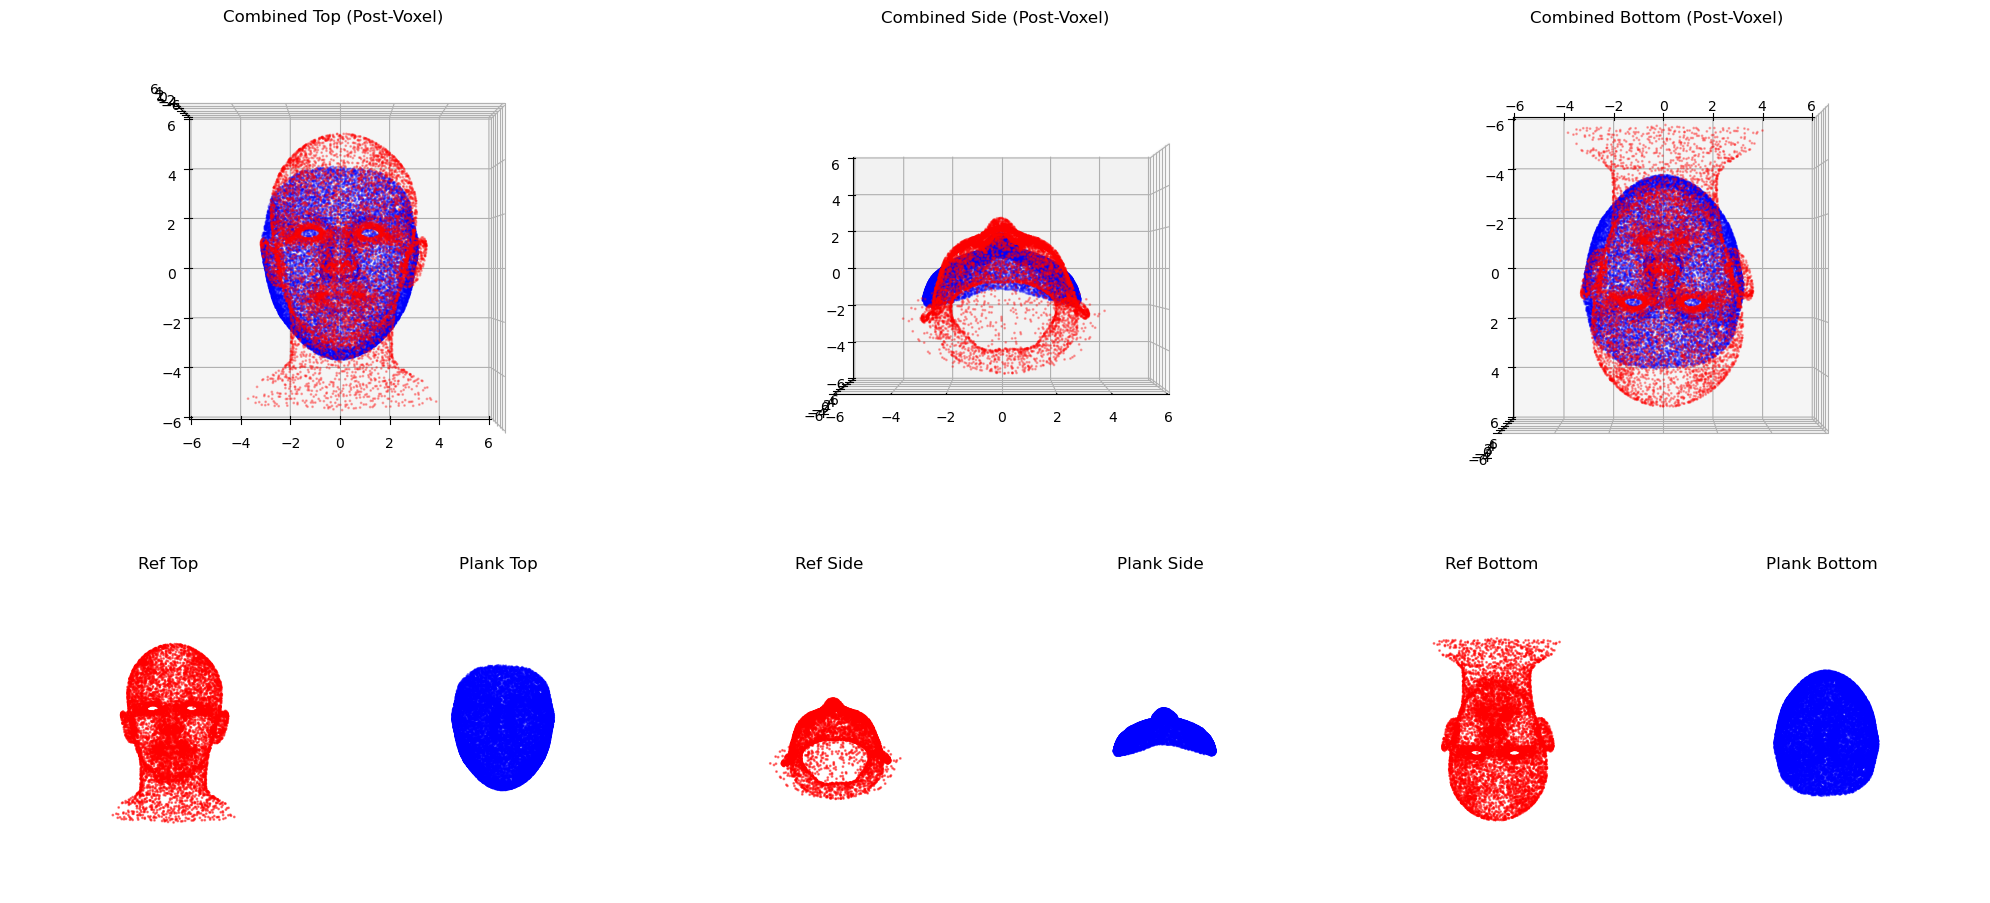

In [40]:
# Voxelization using REF Voxel Size

v_ref_only = bufferx_voxel(ref_norm)
print(f"Ref-calculated Voxel Size: {v_ref_only:.4f}")

# Apply ref-based voxel size to both 
ref_v = voxel_downsample(ref_norm, v_ref_only)
src_v = voxel_downsample(plank_norm, v_ref_only)

print("Rendering: After Voxelization (using Ref Voxel Size)...")
render_comparison(ref_v, src_v, "Post-Voxel")

Point count - Scaled Source (Full): 20000
Point count - Voxelized Source (Downsampled): 15720


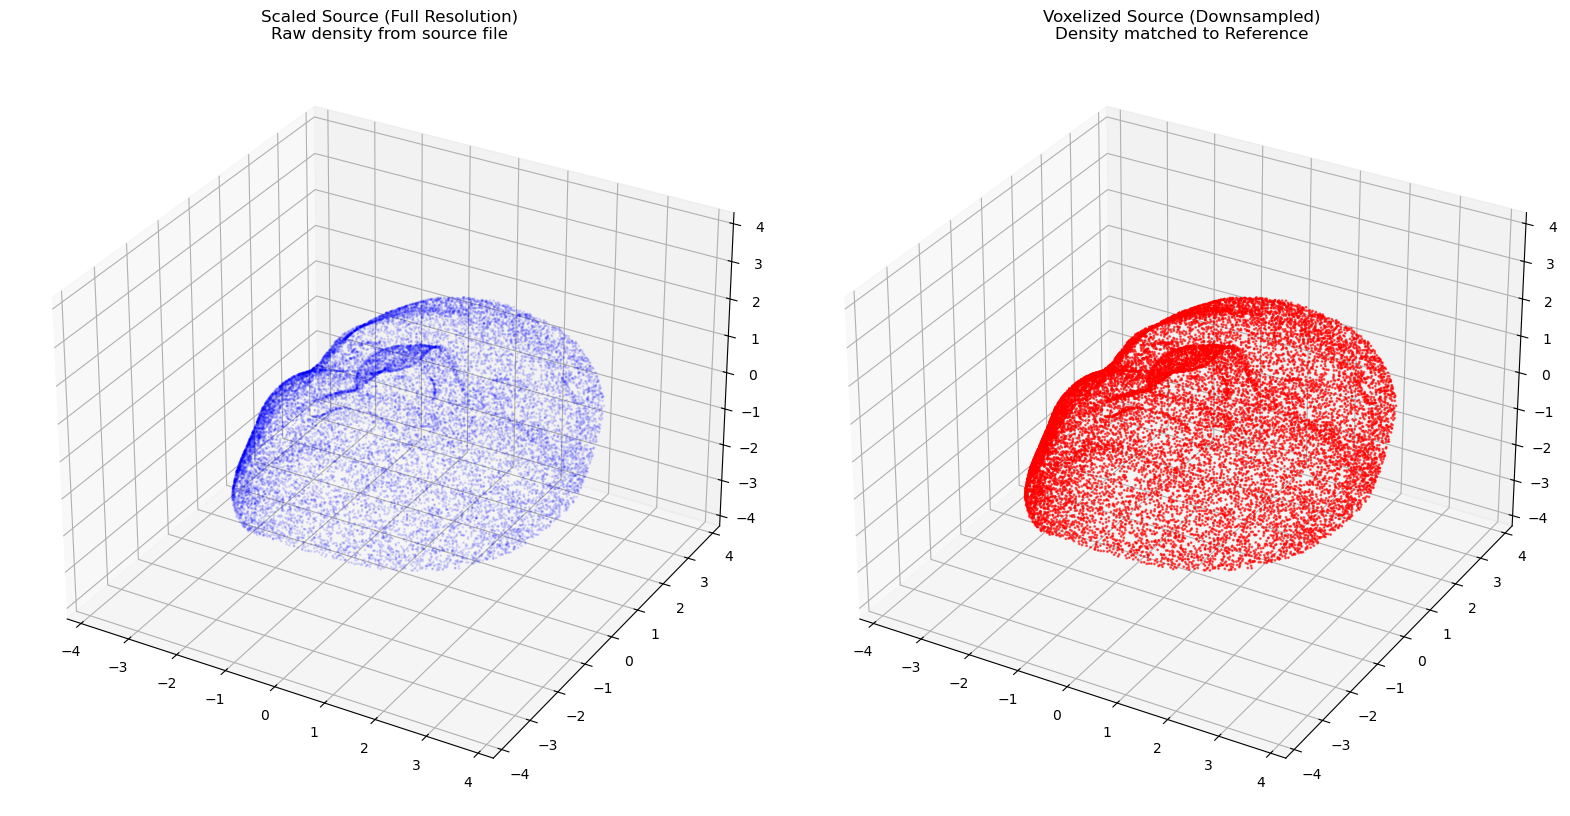

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Print Point Counts
print(f"Point count - Scaled Source (Full): {len(scaled_src)}")
print(f"Point count - Voxelized Source (Downsampled): {len(src_v)}")

# Side-by-Side Plot
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, figure=fig)

all_points = np.vstack([scaled_src, src_v])
max_range = np.max(np.abs(all_points)) * 1.1
lims = [-max_range, max_range]

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax1.scatter(scaled_src[:, 0], scaled_src[:, 1], scaled_src[:, 2], c='blue', s=1, alpha=0.1)
ax1.set_xlim(lims); ax1.set_ylim(lims); ax1.set_zlim(lims)
ax1.view_init(elev=30, azim=-60)
ax1.set_title("Scaled Source (Full Resolution)\nRaw density from source file")

ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax2.scatter(src_v[:, 0], src_v[:, 1], src_v[:, 2], c='red', s=1, alpha=0.6)
ax2.set_xlim(lims); ax2.set_ylim(lims); ax2.set_zlim(lims)
ax2.view_init(elev=30, azim=-60)
ax2.set_title("Voxelized Source (Downsampled)\nDensity matched to Reference")

plt.tight_layout()
plt.show()

In [42]:
print("scaled-src calculated Voxel Size:", bufferx_voxel(scaled_src))
print("src_v calculated Voxel Size:", bufferx_voxel(src_v))
print("ref_v calculated Voxel Size:", bufferx_voxel(ref_v))


scaled-src calculated Voxel Size: 0.029046577483860022
src_v calculated Voxel Size: 0.028734585139331123
ref_v calculated Voxel Size: 0.04030940145272388


In [43]:
print("scaled ref calculated r:", bufferx_radius(ref_norm))
print("scaled src calculated r:", bufferx_radius(plank_norm))

scaled ref calculated r: 0.9798602009141177
scaled src calculated r: 0.9918803693835798
